<a href="https://colab.research.google.com/github/siwarTaha/Prediction-of-Product-Sales/blob/main/Prediction_of_Product_Sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Title: Prediction of Product Sales

Siwar Ehwass

## Project Overview

### Data Dictionary

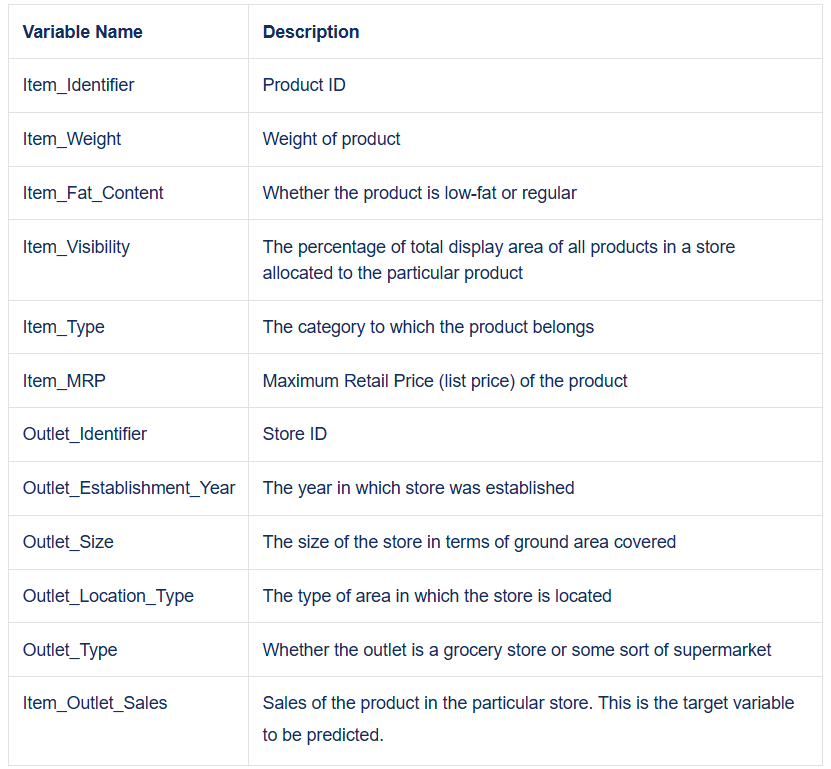

## Load and Inspect Data

### Imports

In [1]:
import pandas as pd
import numpy as np

### Loading Data

In [2]:
path='https://docs.google.com/spreadsheets/d/e/2PACX-1vR6AvAZumX2EE8diEPYfNdktYpa8cELog1Iv_SL7EIFj_DIVxnGwq5liujvJ1GTQry9NDkFsISbeWaE/pub?output=csv'
df=pd.read_csv(path)

In [3]:
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


## Clean Data

### Renaming Columns

In [5]:
# rename columns
rename_dict={'Item_Identifier':'Product id',
             'Item_Weight':'Weight',
             'Item_Fat_Content':'Fat Content',
             'Item_Visibility':'Visibility',
             'Item_Type':'Category',
             'Item_MRP':'Product MRP',
             'Outlet_Identifier':'Store id',
             'Outlet_Establishment_Year':'Year Established',
             'Outlet_Size':'Store size',
             'Outlet_Location_Type':'Area',
             'Outlet_Type':'Store type'}

In [6]:
# apply the changes to the dataframe
df=df.rename(rename_dict,axis=1)
df.head()

,Product id,Weight,Fat Content,Visibility,Category,Product MRP,Store id,Year Established,Store size,Area,Store type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


### Fixing the Data Types
- Fixing Outlet ID from a string to an integer

In [7]:
# fix outlet identifier data type into integer
df['Store id']=df['Store id'].str.replace('OUT','')
df['Store id']=df['Store id'].astype(int)
df['Store id'].dtypes

dtype('int64')

### Duplicated Data

In [8]:
# check for duplicated data
duplicated_rows=df.duplicated(keep=False)
duplicated_rows.sum()

np.int64(0)

- there are no duplicated values

Check for unique values:

In [16]:
# percentage of unique values in each columns
df.nunique() / len(df) * 100

,0
Product id,18.291681
Weight,4.869178
Fat Content,0.058665
Visibility,92.455708
Category,0.187727
Product MRP,69.670304
Store id,0.117330
Year Established,0.105597
Store size,0.035199
Area,0.035199


In [17]:
# how many rows are duplicates when product id and store id identify as unique values
duplicated_id=df.duplicated(subset=['Product id', 'Store id'],keep=False)
duplicated_id.sum()

np.int64(0)

- there are no duplicated values in the data set.

In [20]:
df.head()

,Product id,Weight,Fat Content,Visibility,Category,Product MRP,Store id,Year Established,Store size,Area,Store type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,49,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,18,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,49,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,10,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,13,1987,High,Tier 3,Supermarket Type1,994.7052


## Exploratory Data Analysis

## Feature Inspection